# 2. Data Preparation

> **CRISP-DM Phase 3:** Transform raw data into a clean, merged **Analytical Base Table (ABT)** ready for modelling.

## Overview

| Step | Description |
|------|-------------|
| 2.1  | Load raw datasets |
| 2.2  | Clean `bdoss` (loan-level) - type casting, RISK encoding, imputation, OHE |
| 2.3  | Clean `crc` (credit bureau monthly) - imputation, derived aggregates |
| 2.4  | Clean `credscore` (credit score) - ordinal encoding, deduplication |
| 2.5  | Clean `fama` (customer aggregates) - OHE, deduplication |
| 2.6  | Merge into a single ABT |
| 2.7  | ABT quality check & target distribution |
| 2.8  | Save ABT (so we can use it in posterior notebooks) |

---
## Setup

In [1]:
import importlib
import sys, os

# Ensure project root is on path
sys.path.insert(0, os.path.abspath(".."))

import src.code.data_preparation as dp
import src.code.data_functions as dfun
import src.code.io_utils as io

importlib.reload(dp)
importlib.reload(dfun)
importlib.reload(io)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# Path constants
BDOSS_PATH    = io.data_path("bdoss.csv")
CRC_PATH      = io.data_path("crc.csv")
CREDSCORE_PATH = io.data_path("credscore.csv")
FAMA_PATH     = io.data_path("fama.csv")
ABT_OUT_PATH  = "../data/prepared/abt.parquet"

print("Setup complete.")

Setup complete.


---
## 2.1 Load Raw Datasets

> All four datasets are loaded from the `../data/converted/` folder (CSV format).  
> Loading uses `io_utils.load()`, which prints shape information automatically.

In [2]:
# Main loan-level dataset - large, takes a few seconds to load
bdoss_raw = io.load(BDOSS_PATH)
bdoss_raw.head(3)

[LOAD] ../data/converted/bdoss.csv | shape: (2658187, 35)


,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.000,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.000,69.000,69.000,20000.000,20000.000,347.447,NaN,13208.455,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,120.000,P,1113.258,80.000,1988.000,P,2845,1.000,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.000,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.000,34.000,34.000,2500.000,2500.000,56.018,NaN,0.000,0.000,NaN,1.000,1.000,000000000000210210000110,0.000,120.000,N,838.186,91.000,1990.000,P,2855,0.000,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.000,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.000,52.000,52.000,5000.000,5000.000,100.074,NaN,2665.191,0.000,NaN,0.000,0.000,000000000000000000000000,0.000,118.000,P,1314.144,80.000,2013.000,P,2635,2.000,W


In [3]:
# Credit bureau monthly data
crc_raw = io.load(CRC_PATH)
crc_raw.head(3)

[LOAD] ../data/converted/crc.csv | shape: (3034921, 22)


,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.000,4.000,0.000,0.000,0.000,1.000,6.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6842.100,963.550,0.000,0.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,2023-12-31,547.180,4.000,5.000,0.000,0.000,0.000,1.000,10.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,28532.060,7115.460,0.000,0.000
2,0000f858346061c53064586a3347b34659565a6712d004...,2023-12-31,NaN,1.000,5.000,1.000,1.000,0.000,0.000,8.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2957.280,2150.900,2408.560,85549.490


In [4]:
# Credit score per customer
credscore_raw = io.load(CREDSCORE_PATH)
credscore_raw.head(3)

[LOAD] ../data/converted/credscore.csv | shape: (63704, 5)


,CONTRIB,sys_numero_submissao,sys_data_procura,kp_sqe,ks_score_tier
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,22.000,2025-02-05,H,2.000
1,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,4.000,2025-04-09,D,1.000
2,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,1.000,2023-08-08,F,3.000


In [5]:
# Aggregated customer-level features + socio-demographics
fama_raw = io.load(FAMA_PATH)
fama_raw.head(3)

[LOAD] ../data/converted/fama.csv | shape: (141115, 23)


,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.000,6.000,9.000,1.000,0.000,88784.040,0.000,88784.040,0.000,4443.000,-808.000,1280.533,0.000,1153.000,1153.000,120.000,0.425,15.000,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.000,4.000,2.000,1.000,2.000,9584.910,7628.410,9584.910,0.000,3120.000,-2077.000,466.333,14.000,1564.667,1582.000,72.000,0.139,6.000,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.000,5.000,3.000,1.000,0.000,22000.860,0.000,22000.860,0.000,4936.000,-2089.000,907.625,0.000,1765.000,1765.000,36.000,0.278,8.000,C,L,65


---
## 2.2 Clean `bdoss`

**Key operations:**
- Parse datetime columns (`OBS_DATE`, `DCREAT`, `DATFIN`, etc.)
- Encode `RISK` $\rightarrow$ binary: `1` if any of the 24 monthly risk chars is non-zero, `0` otherwise
- Derive `loan_age_months` and `remaining_months` from dates
- Impute numeric missing values with column medians
- One-hot encode nominal categoricals (`POS`, `PAGAMENTO`, `NATIO`, etc.)
- Drop raw date columns and loan-ID (`DOSSIER`)

In [6]:
bdoss_clean = dp.clean_bdoss(bdoss_raw)

print(f"\nShape before: {bdoss_raw.shape}  vs  after: {bdoss_clean.shape}")
print(f"\nMissing values per column (only cols with >0 nulls):")
miss = bdoss_clean.isnull().sum()
display(miss[miss > 0].sort_values(ascending=False).to_frame("null_count"))

[clean_bdoss] shape: (2658187, 47) | RISK distribution:
{0: 2327930, 1: 330257}

Shape before: (2658187, 35)  vs  after: (2658187, 47)

Missing values per column (only cols with >0 nulls):


,null_count


RISK value counts:
RISK
0    2327930
1     330257
Name: count, dtype: int64

Null RISK values: 0


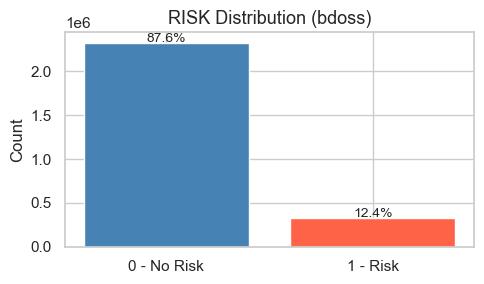

In [7]:
# Quick sanity check on the RISK encoding
print("RISK value counts:")
print(bdoss_clean["RISK"].value_counts())
print(f"\nNull RISK values: {bdoss_clean['RISK'].isnull().sum()}")

fig, ax = plt.subplots(figsize=(5, 3))
risk_counts = bdoss_clean["RISK"].value_counts().sort_index()
ax.bar(["0 - No Risk", "1 - Risk"], risk_counts.values, color=["steelblue", "tomato"])
ax.set_title("RISK Distribution (bdoss)", fontsize=13)
ax.set_ylabel("Count")
for i, v in enumerate(risk_counts.values):
    ax.text(i, v + 5000, f"{v / risk_counts.sum() * 100:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
# Preview derived time-based features
time_cols = [c for c in ["loan_age_months", "remaining_months"] if c in bdoss_clean.columns]
if time_cols:
    display(bdoss_clean[time_cols].describe())

,loan_age_months,remaining_months
count,2658187.000,2658187.000
mean,32.816,42.206
std,31.142,36.037
min,-2.000,-314.000
25%,10.000,20.000
50%,25.000,43.000
75%,48.000,67.000
max,338.000,157.000


loan_age_months has min=-2, which seems like an error... right? what should we do about this?

---
## 2.3 Clean `crc`

**Key operations:**
- Parse `OBS_DATE`
- Fill `COUNT_*`, `MONTVENC_*`, `MONTABATV_*`, `DIVIDAS_*` with `0` (absence = no exposure)
- Impute `MT_MENSAL` (total monthly credit obligations) with median
- Derive `crc_total_overdue` and `crc_total_debt` aggregate columns

In [9]:
crc_clean = dp.clean_crc(crc_raw)

print(f"Shape before: {crc_raw.shape}  vs  after: {crc_clean.shape}")
miss = crc_clean.isnull().sum()
print(f"\nRemaining nulls: {miss[miss > 0].to_dict()}")
crc_clean[["crc_total_overdue", "crc_total_debt"]].describe()

[clean_crc] shape: (3034921, 24)
Shape before: (3034921, 22)  vs  after: (3034921, 24)

Remaining nulls: {}


,crc_total_overdue,crc_total_debt
count,3034921.000,3034921.000
mean,208.935,49914.141
std,4310.629,66385.666
min,0.000,0.000
25%,0.000,10125.110
50%,0.000,25251.430
75%,0.000,68425.250
max,2924186.680,5003151.840


---
## 2.4 Clean `credscore`

**Key operations:**
- Parse `sys_data_procura` (date of credit score query)
- Ordinal-encode `kp_sqe`: A $\rightarrow$ 0 (best) ... H $\rightarrow$ 7 (worst)
- Keep only the **most recent** record per `CONTRIB`

In [10]:
credscore_clean = dp.clean_credscore(credscore_raw)

print(f"Shape before: {credscore_raw.shape}  vs  after: {credscore_clean.shape}")
display(credscore_clean.head())
print("\nkp_sqe_enc value counts:")
display(credscore_clean["kp_sqe_enc"].value_counts().sort_index())

[clean_credscore] shape: (62173, 3)
Shape before: (63704, 5)  vs  after: (62173, 3)


,CONTRIB,ks_score_tier,kp_sqe_enc
0,8863a99c003d8696cb368041406f8e90d30dacaff11951...,1.000,NaN
1,d5122ff2a3f1e3dda8d2381d548a500191b90e1e3377f8...,3.000,1.000
2,0f162bbfd015407938c0b38bddbd36ec63f46301d513a2...,1.000,1.000
3,e8980775f178b9a8048b1b5c73f8a177824aa0d1a00bff...,1.000,NaN
4,2a987a1d06e8909b478999e9cd4956424faf90d0322a93...,3.000,4.000



kp_sqe_enc value counts:


kp_sqe_enc
0.000    6895
1.000    5339
2.000    4138
3.000    4552
4.000    6165
5.000    5974
6.000    3295
7.000    4601
Name: count, dtype: int64

---
## 2.5 Clean `fama`

**Key operations:**
- Parse `Date_Obs`
- Keep most-recent record per `CONTRIB`
- One-hot encode `sdem_SITFAM` (family situation) and `sdem_HABITAT` (housing type)
- Impute remaining numeric nulls with column medians

In [11]:
fama_clean = dp.clean_fama(fama_raw)

print(f"Shape before: {fama_raw.shape}  vs  after: {fama_clean.shape}")
miss = fama_clean.isnull().sum()
print(f"\nRemaining nulls: {miss[miss > 0].to_dict()}")
display(fama_clean.head(3))

[clean_fama] shape: (141115, 36)
Shape before: (141115, 23)  vs  after: (141115, 36)

Remaining nulls: {}


,CONTRIB,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,sdem_SITFAM_C,sdem_SITFAM_D,sdem_SITFAM_F,sdem_SITFAM_P,sdem_SITFAM_S,sdem_SITFAM_U,sdem_SITFAM_V,sdem_SITFAM_X,sdem_HABITAT_0,sdem_HABITAT_A,sdem_HABITAT_E,sdem_HABITAT_F,sdem_HABITAT_L,sdem_HABITAT_O,sdem_HABITAT_P,sdem_HABITAT_X
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,15.000,6.000,9.000,1.000,0.000,88784.040,0.000,88784.040,0.000,4443.000,-808.000,1280.533,0.000,1153.000,1153.000,120.000,0.425,15.000,62,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,9f8de7af5812cdea8ceb0864b8d5318a6c8d5e42a50003...,6.000,6.000,0.000,1.000,0.000,16000.000,0.000,16000.000,0.000,1172.000,-2180.000,-422.000,0.000,708.000,708.000,60.000,0.117,6.000,37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,7e8a7fe69a2908922ae65a18fd775287f2e1691dc64f26...,22.000,18.000,4.000,0.000,0.000,533.100,0.000,533.100,0.000,4625.000,-1903.000,1554.182,0.000,0.000,0.000,0.000,0.000,22.000,39,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0


---
## 2.6 Merge Datasets $\rightarrow$ Analytical Base Table (ABT)

Join strategy:
```
bdoss (base)   LEFT JOIN  crc        ON [CONTRIB, OBS_DATE]
               LEFT JOIN  credscore  ON [CONTRIB]
               LEFT JOIN  fama       ON [CONTRIB]
```
Using **left join** ensures we keep all bdoss records even if bureau/score data is missing for some customers.

In [12]:
abt = dp.merge_datasets(bdoss_clean, crc_clean, credscore_clean, fama_clean)

print(f"\nFinal ABT shape: {abt.shape}")
display(abt.head(3))

[merge] Starting merge...
[merge] Final ABT shape: (2658187, 106)
[merge] Overall missing: 2.87%
[merge] RISK distribution:
{0: 2327930, 1: 330257}

Final ABT shape: (2658187, 106)


,CONTRIB,BICONTRATO,OBS_DATE,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,RN,RD,RISK,RISKA,AGFIN,RESSO,CSP,PTT,NBENF,loan_age_months,remaining_months,POS_ENC,POS_RBT,POS_SAN,POS_SOL,PAGAMENTO_M,PAGAMENTO_N,PAGAMENTO_P,...,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,sdem_SITFAM_C,sdem_SITFAM_D,sdem_SITFAM_F,sdem_SITFAM_P,sdem_SITFAM_S,sdem_SITFAM_U,sdem_SITFAM_V,sdem_SITFAM_X,sdem_HABITAT_0,sdem_HABITAT_A,sdem_HABITAT_E,sdem_HABITAT_F,sdem_HABITAT_L,sdem_HABITAT_O,sdem_HABITAT_P,sdem_HABITAT_X
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,0.000,2024-01-31,120.000,69.000,69.000,20000.000,20000.000,347.447,347.447,13208.455,0.000,0.000,0.000,0,0.000,120.000,1113.258,80.000,2845,1.000,70,50,1,0,0,0,0,0,1,...,20000.000,0.000,20000.000,0.000,4453.000,-1928.000,1166.900,0.000,850.000,850.000,120.000,0.675,10.000,52.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,0.000,2024-01-31,72.000,34.000,34.000,2500.000,2500.000,56.018,56.018,0.000,0.000,1.000,1.000,1,0.000,120.000,838.186,91.000,2855,0.000,60,12,0,0,1,0,0,1,0,...,2500.000,0.000,2500.000,0.000,2216.000,-233.000,590.333,0.000,0.000,0.000,0.000,0.000,3.000,69.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0000f858346061c53064586a3347b34659565a6712d004...,0.000,2024-01-31,84.000,52.000,52.000,5000.000,5000.000,100.074,100.074,2665.191,0.000,0.000,0.000,0,0.000,118.000,1314.144,80.000,2635,2.000,52,32,1,0,0,0,0,0,1,...,5000.000,13477.220,5000.000,0.000,3060.000,-443.000,1358.250,553.000,898.500,997.000,84.000,0.762,4.000,39.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000


---
## 2.7 ABT Quality Check

Verify:
- No column is 100% null
- `RISK` is a clean binary integer
- Overall missing-value rate is acceptable

In [ ]:
# Assertions 
assert abt.shape[0] > 0, "ABT is empty!"
assert "RISK" in abt.columns, "RISK column missing!"
assert abt["RISK"].isin([0, 1]).all(), "RISK is not binary!"
assert abt["RISK"].isnull().sum() == 0, "RISK has nulls!"
assert (abt.isnull().mean() < 1.0).all(), "Some column is 100% null!"

print("All assertions passed.")

All assertions passed.


In [ ]:
# Missing values overview
null_pct = (abt.isnull().sum() / len(abt) * 100).round(2)
null_summary = null_pct[null_pct > 0].sort_values(ascending=False)
print(f"Columns with missing values ({len(null_summary)} / {abt.shape[1]}):")
if len(null_summary) > 0:
    display(null_summary.to_frame("null_pct"))
else:
    print("None! ABT is fully complete")

overall_null = abt.isnull().sum().sum() / abt.size * 100
print(f"\nOverall missing: {overall_null:.2f}%")

Columns with missing values (59 / 106):


,null_pct
kp_sqe_enc,70.120
ks_score_tier,59.960
MT_MENSAL,5.220
MONTABATV_CP,5.220
COUNT_CL,5.220
crc_total_debt,5.220
DIVIDAS_HT,5.220
DIVIDAS_AUTO,5.220
DIVIDAS_CP,5.220
DIVIDAS_CL,5.220



Overall missing: 2.87%


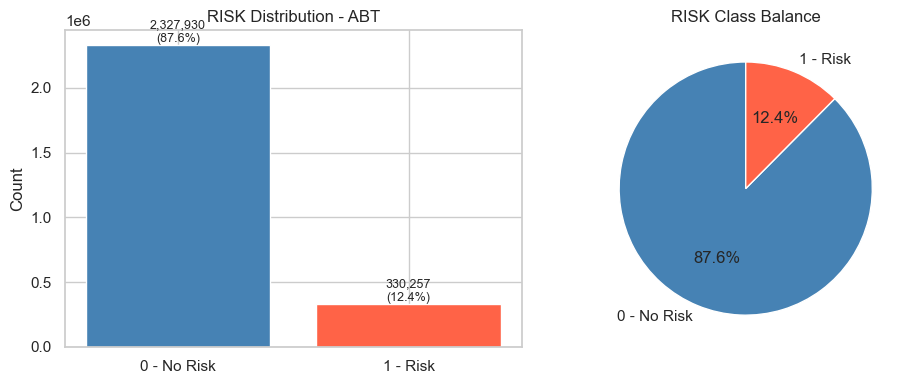


Imbalance ratio (risk:no-risk): 1:7.0


In [ ]:
# RISK class balance
risk_counts = abt["RISK"].value_counts().sort_index()
labels = ["0 - No Risk", "1 - Risk"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, risk_counts.values, color=["steelblue", "tomato"], edgecolor="white")
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}\n({v / risk_counts.sum() * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("RISK Distribution - ABT", fontsize=12)
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(risk_counts.values, labels=labels,
            colors=["steelblue", "tomato"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1].set_title("RISK Class Balance", fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio (risk:no-risk): 1:{risk_counts[0] / risk_counts[1]:.1f}")

In [ ]:
# Data types summary
dtype_counts = abt.dtypes.value_counts()
print("Column dtype distribution:")
display(dtype_counts.to_frame("count"))

# List any remaining object columns (should be only CONTRIB)
obj_cols = abt.select_dtypes(include="object").columns.tolist()
print(f"\nRemaining object columns: {obj_cols}")

Column dtype distribution:


,count
float64,76
int8,24
Int64,3
object,1
datetime64[ns],1
int64,1



Remaining object columns: ['CONTRIB']


In [ ]:
# Feature overview
print(f"Total features in ABT: {abt.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(abt.columns, 1):
    print(f"  {i:3d}. {col}")

Total features in ABT: 106

All columns:
    1. CONTRIB
    2. BICONTRATO
    3. OBS_DATE
    4. DURDEG
    5. RANGPRO
    6. RANGCLI
    7. MTFINO
    8. MTFIN
    9. MENSALIDADE
   10. MENSALIDADE_CORR
   11. CRD
   12. SREC
   13. RN
   14. RD
   15. RISK
   16. RISKA
   17. AGFIN
   18. RESSO
   19. CSP
   20. PTT
   21. NBENF
   22. loan_age_months
   23. remaining_months
   24. POS_ENC
   25. POS_RBT
   26. POS_SAN
   27. POS_SOL
   28. PAGAMENTO_M
   29. PAGAMENTO_N
   30. PAGAMENTO_P
   31. NATIO_C
   32. NATIO_D
   33. NATIO_P
   34. NATIO_X
   35. MODCONTACTO_A
   36. MODCONTACTO_C
   37. MODCONTACTO_T
   38. MODCONTACTO_V
   39. MODCONTACTO_W
   40. MODCONTACTO_X
   41. POLE_N
   42. POLE_P
   43. TYPEPROD_CL
   44. PRODALP_DEF
   45. PRODALP_EP
   46. PRODALP_EPF
   47. PRODALP_EXT
   48. MT_MENSAL
   49. COUNT_CL
   50. COUNT_CP
   51. COUNT_AUTO
   52. COUNT_HT
   53. COUNT_CONEXO
   54. COUNT_OTHER
   55. COUNT_TOTAL
   56. MONTVENC_CL
   57. MONTVENC_CP
   58. MONTVENC_

---
## 2.8 Save ABT

The ABT is saved as a **Parquet file** to `../data/prepared/abt.parquet`.  
Parquet preserves dtypes and is significantly faster to read than CSV for large tables.

In [ ]:
io.save(abt, ABT_OUT_PATH)

# Verify file exists and reload sanity check
import os
assert os.path.exists(ABT_OUT_PATH), "ABT file not found after save!"

abt_check = pd.read_parquet(ABT_OUT_PATH)
assert abt_check.shape == abt.shape, "Reloaded shape mismatch!"
print(f"\nABT successfully saved and verified: {ABT_OUT_PATH}")
print(f"   Rows: {abt_check.shape[0]:,}  |  Columns: {abt_check.shape[1]}")

[save] ABT saved -> ../data/prepared/abt.parquet  |  shape: (2658187, 106)

ABT successfully saved and verified: ../data/prepared/abt.parquet
   Rows: 2,658,187  |  Columns: 106
